# 📦 ParcelCast — Notebook 2
## Modeling: Baseline / Prophet / LightGBM

**Purpose:** Build and compare forecasting models using the parcel team's
exact metrics (Traditional Error + WMAPE) plus a lag analysis that mirrors
the WPR report format.

**Models:**
1. **4-week MA** — naive baseline, the floor
2. **Prophet** — yearly seasonality + US retail holidays
3. **LightGBM** — global model with lag/calendar/UPP features

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from src.evaluation import all_metrics, build_scorecard, lag_analysis
from src.features import build_feature_set, get_feature_columns, get_feature_table
from src.models import LightGBMForecaster, MovingAverageBaseline, ProphetModel

sns.set_theme(style="whitegrid", palette="muted")
PRESENTATION_DIR = Path.cwd().parent / "presentation"
DATA_DIR = Path.cwd().parent / "data"

TEST_WEEKS = 12  # Hold out last 12 weeks for evaluation

## 1. Load cleaned data

In [2]:
weekly = pd.read_parquet(DATA_DIR / "weekly_region_channel.parquet")
weekly["week_start"] = pd.to_datetime(weekly["week_start"])
print(f"Loaded {len(weekly):,} rows")
weekly.head()

Loaded 1,662 rows


,region,channel,wm_yr_wk,week_start,units,upp,packages
0,WEST,1P,11101,2011-01-29,72459,2.100000,34504.285714
1,WEST,1P,11102,2011-02-05,76606,2.098774,36500.348456
2,WEST,1P,11103,2011-02-12,66480,2.097550,31694.124114
3,WEST,1P,11104,2011-02-19,64972,2.096326,30993.277037
4,WEST,1P,11105,2011-02-26,67064,2.095102,32009.893921


In [3]:
# Aggregate to network-level weekly packages (across regions/channels)
network = (
    weekly.groupby("week_start", as_index=False)
    .agg(packages=("packages", "sum"), upp=("upp", "mean"))
)
print(f"Network-level weeks: {len(network)}")

train = network.iloc[:-TEST_WEEKS].copy()
test = network.iloc[-TEST_WEEKS:].copy()
print(f"Train: {len(train)} weeks, Test: {len(test)} weeks")

Network-level weeks: 277
Train: 265 weeks, Test: 12 weeks


## 2. Baseline: 4-week moving average

In [4]:
baseline = MovingAverageBaseline(window=4).fit(train, target_col="packages")
baseline_pred = baseline.predict(TEST_WEEKS)
baseline_metrics = all_metrics(test["packages"].values, baseline_pred)
print(f"Baseline metrics: {baseline_metrics}")

Baseline metrics: {'traditional_error_pct': np.float64(-1.86), 'wmape_pct': np.float64(3.96)}


## 3. Prophet with US retail holidays

In [5]:
prophet = ProphetModel(seasonality_mode="multiplicative").fit(
    train, date_col="week_start", target_col="packages",
)
prophet_forecast = prophet.predict_with_intervals(TEST_WEEKS)
prophet_pred = prophet_forecast["yhat"].values
prophet_metrics = all_metrics(test["packages"].values, prophet_pred)
print(f"Prophet metrics: {prophet_metrics}")

05:19:39 - cmdstanpy - INFO - Chain [1] start processing


05:19:39 - cmdstanpy - INFO - Chain [1] done processing


Prophet metrics: {'traditional_error_pct': np.float64(-5.56), 'wmape_pct': np.float64(5.88)}


## 4. LightGBM (global model — all region × channel series)

In [6]:
# Build feature set on the disaggregated data
featured = build_feature_set(weekly, target_col="packages")
feature_cols = [c for c in get_feature_columns(featured) if c not in {"upp"}]
# (Drop bare `upp` to avoid leakage with target since UPP is used in the conversion)

# Train/test split — same date cutoff as Prophet
cutoff_date = train["week_start"].max()
lgbm_train = featured[featured["week_start"] <= cutoff_date]
lgbm_test = featured[featured["week_start"] > cutoff_date]

print(f"LightGBM train: {len(lgbm_train):,} rows, test: {len(lgbm_test):,} rows")
print(f"Features ({len(feature_cols)}): {feature_cols}")

LightGBM train: 1,590 rows, test: 72 rows
Features (18): ['lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_52', 'yoy_growth', 'year', 'month', 'quarter', 'fiscal_week', 'woy_sin', 'woy_cos', 'is_peak', 'is_bts', 'is_holiday', 'upp_lag_1', 'upp_lag_4']


In [7]:
lgbm = LightGBMForecaster()
lgbm.fit(lgbm_train, feature_cols, target_col="packages", n_estimators=500)
lgbm_test_preds = lgbm.predict(lgbm_test)

# Aggregate to network-level for comparison with other models
lgbm_test_df = lgbm_test.copy()
lgbm_test_df["pred"] = lgbm_test_preds
lgbm_network_pred = lgbm_test_df.groupby("week_start")["pred"].sum().sort_index().values
lgbm_network_actual = lgbm_test_df.groupby("week_start")["packages"].sum().sort_index().values

lgbm_metrics = all_metrics(lgbm_network_actual, lgbm_network_pred)
print(f"LightGBM metrics: {lgbm_metrics}")

LightGBM metrics: {'traditional_error_pct': np.float64(-0.64), 'wmape_pct': np.float64(1.55)}


### Feature importance (LightGBM)

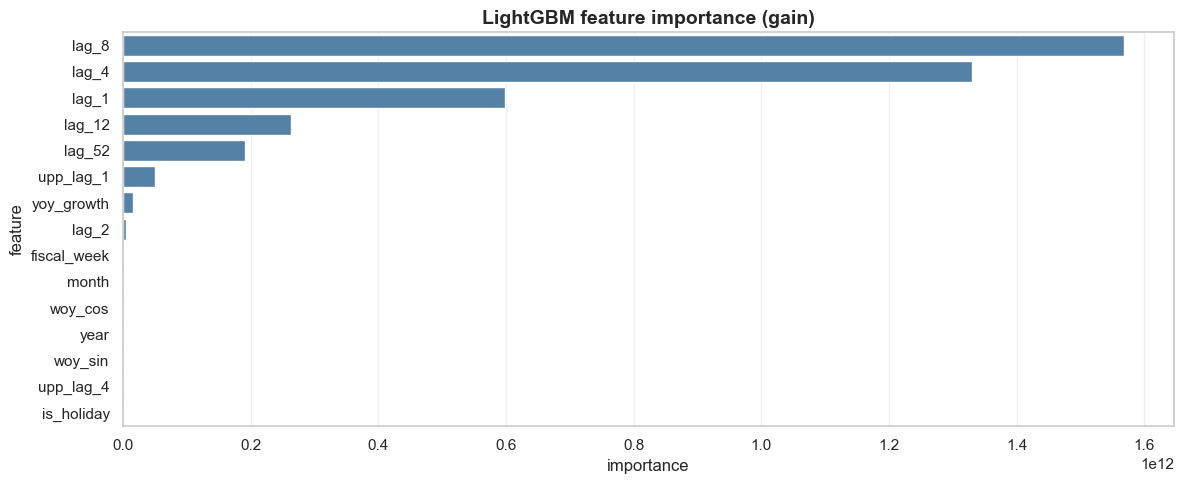

In [8]:
fi = lgbm.feature_importance(top_n=15)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=fi, x="importance", y="feature", ax=ax, color="steelblue")
ax.set_title("LightGBM feature importance (gain)",
             fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Model Scorecard

In [9]:
scorecard = build_scorecard(
    test["packages"].values,
    {
        "Baseline (4wk MA)": baseline_pred,
        "Prophet": prophet_pred,
        "LightGBM": lgbm_network_pred,
    },
)
scorecard

,model,traditional_error_pct,wmape_pct,rank_wmape
0,LightGBM,-0.64,1.55,1
1,Baseline (4wk MA),-1.86,3.96,2
2,Prophet,-5.56,5.88,3


In [10]:
scorecard.to_csv(DATA_DIR / "model_scorecard.csv", index=False)

## 6. Forecast vs Actuals (visualization)

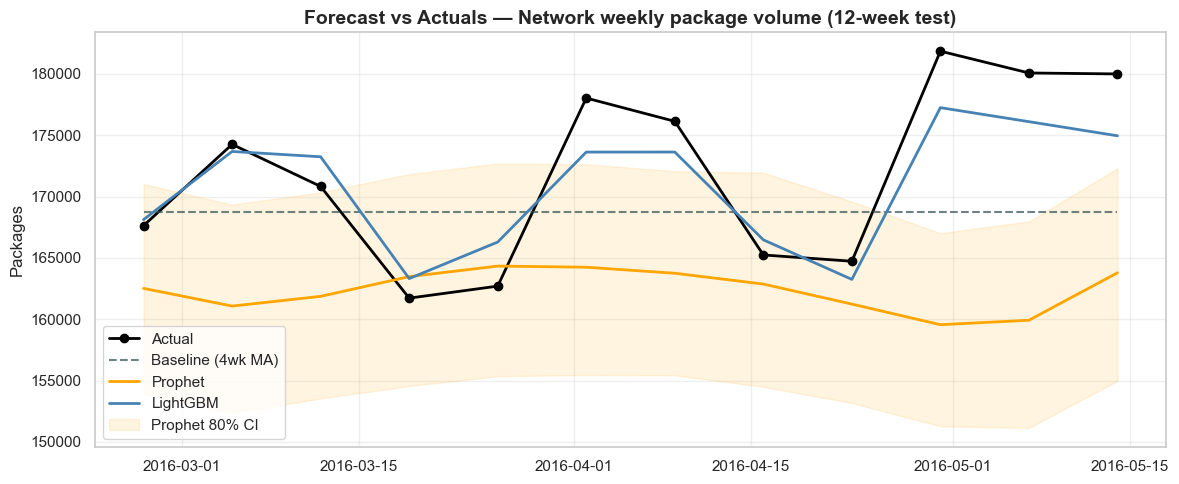

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test["week_start"], test["packages"], color="black",
        marker="o", label="Actual", linewidth=2)
ax.plot(test["week_start"], baseline_pred, "--",
        label="Baseline (4wk MA)", color="darkslategray", alpha=0.7)
ax.plot(test["week_start"], prophet_pred, "-",
        label="Prophet", color="orange", linewidth=2)
ax.plot(test["week_start"], lgbm_network_pred, "-",
        label="LightGBM", color="steelblue", linewidth=2)
ax.fill_between(
    test["week_start"],
    prophet_forecast["yhat_lower"].values,
    prophet_forecast["yhat_upper"].values,
    color="orange", alpha=0.12, label="Prophet 80% CI",
)
ax.set_title("Forecast vs Actuals — Network weekly package volume (12-week test)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Packages")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "05_forecast_vs_actuals.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Lag Analysis (mirrors WPR format)

Show how forecast accuracy improves as we get closer to the target week.
This is the format the team already uses.

This matches the WPR lag-analysis format and shows accuracy degradation as
forecast horizon extends — the same pattern reported there.

In [12]:
# For each lag in {1,2,3,4}, generate a "rolling lag-N forecast":
# at each week t, predict t using the model trained on data up to t-N.
# Simplified version: use Prophet, since it's the strongest baseline.

def rolling_lag_forecast(series_df: pd.DataFrame, lag: int, n_test_weeks: int) -> pd.Series:
    """For each test week, forecast it from data ending `lag` weeks earlier."""
    preds = []
    dates = []
    n_total = len(series_df)
    for i in range(n_total - n_test_weeks, n_total):
        train_end = i - lag + 1
        if train_end < 52:
            continue
        sub_train = series_df.iloc[:train_end]
        try:
            m = ProphetModel().fit(sub_train, date_col="week_start", target_col="packages")
            pred = m.predict(lag)[-1]
            preds.append(pred)
            dates.append(series_df.iloc[i]["week_start"])
        except Exception:
            preds.append(np.nan)
            dates.append(series_df.iloc[i]["week_start"])
    return pd.Series(preds, index=dates, name=f"lag_{lag}_forecast")

In [13]:
# Rolling lag forecasts (this takes a few minutes — narrow the test window if needed)
LAGS = [1, 2, 3, 4]
forecasts_by_lag = {}
for lag in LAGS:
    print(f"  Computing lag-{lag} forecasts...")
    forecasts_by_lag[lag] = rolling_lag_forecast(network, lag, TEST_WEEKS)

actuals_indexed = network.set_index("week_start")["packages"].tail(TEST_WEEKS)
lag_table = lag_analysis(actuals_indexed, forecasts_by_lag)
lag_table

05:19:41 - cmdstanpy - INFO - Chain [1] start processing


05:19:41 - cmdstanpy - INFO - Chain [1] done processing


05:19:41 - cmdstanpy - INFO - Chain [1] start processing


05:19:41 - cmdstanpy - INFO - Chain [1] done processing


  Computing lag-1 forecasts...


...

05:19:45 - cmdstanpy - INFO - Chain [1] start processing


05:19:45 - cmdstanpy - INFO - Chain [1] done processing


05:19:45 - cmdstanpy - INFO - Chain [1] start processing


05:19:45 - cmdstanpy - INFO - Chain [1] done processing


,lag_weeks,traditional_error_pct,wmape_pct,n_obs
0,1,-4.04,4.88,12
1,2,-4.54,5.17,12
2,3,-4.82,5.24,12
3,4,-4.97,5.32,12


In [14]:
# Save in the WPR reporting format: row label = "N week(s)",
# columns = "Traditional Error %" and "WMAPE %". Drops the engineering-only n_obs.
wpr_lag = pd.DataFrame({
    "Lag": [f"{n} week" if n == 1 else f"{n} weeks" for n in lag_table["lag_weeks"]],
    "Traditional Error %": lag_table["traditional_error_pct"].round(2),
    "WMAPE %": lag_table["wmape_pct"].round(2),
})
wpr_lag.to_csv(DATA_DIR / "lag_analysis.csv", index=False)
wpr_lag

,Lag,Traditional Error %,WMAPE %
0,1 week,-4.04,4.88
1,2 weeks,-4.54,5.17
2,3 weeks,-4.82,5.24
3,4 weeks,-4.97,5.32


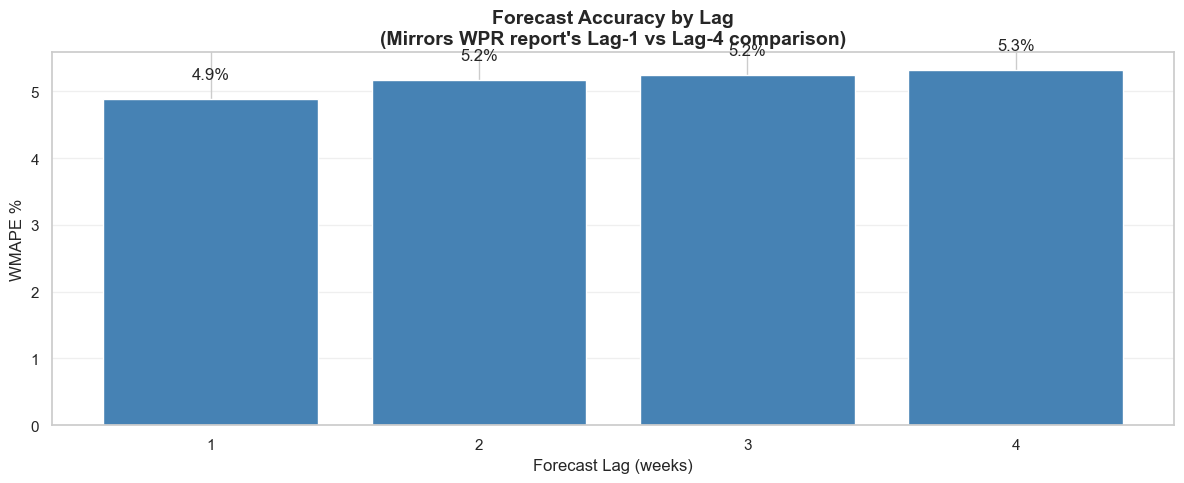

In [15]:
# Visualize the Lag analysis
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(lag_table["lag_weeks"].astype(str), lag_table["wmape_pct"], color="steelblue")
for i, row in lag_table.iterrows():
    ax.text(i, row["wmape_pct"] + 0.3, f"{row['wmape_pct']:.1f}%", ha="center")
ax.set_xlabel("Forecast Lag (weeks)")
ax.set_ylabel("WMAPE %")
ax.set_title("Forecast Accuracy by Lag\n(Mirrors WPR report's Lag-1 vs Lag-4 comparison)",
             fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "06_lag_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save Prophet forecast for the business notebook

In [16]:
prophet_forecast["week_start"] = prophet_forecast["ds"]
prophet_forecast["packages_forecast"] = prophet_forecast["yhat"]
prophet_forecast["packages_low"] = prophet_forecast["yhat_lower"]
prophet_forecast["packages_high"] = prophet_forecast["yhat_upper"]
prophet_forecast[["week_start", "packages_forecast", "packages_low", "packages_high"]].to_parquet(
    DATA_DIR / "network_forecast.parquet", index=False,
)
print("Saved Prophet forecast for business notebook.")

Saved Prophet forecast for business notebook.


## 9. Feature documentation table (for the deck)

In [17]:
feature_table = get_feature_table(feature_cols)
feature_table

,feature,business_justification
0,lag_1,Last week's volume — strongest single predicto...
1,lag_2,2-week-ago volume — captures very-short-term m...
2,lag_4,4-week-ago volume — captures monthly cycle
3,lag_8,8-week-ago volume — early indicator of trend s...
4,lag_12,12-week-ago (quarterly) volume
5,lag_52,Same week last year — captures annual seasonal...
6,yoy_growth,Year-over-year growth rate — captures structur...
7,year,—
8,month,Month — coarser seasonality
9,quarter,Quarter — quarterly business cycle
